In [6]:
import pandas as pd

df = pd.read_csv('/content/Loan_Default.csv')

display(df.head())
display(df.info())

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

None

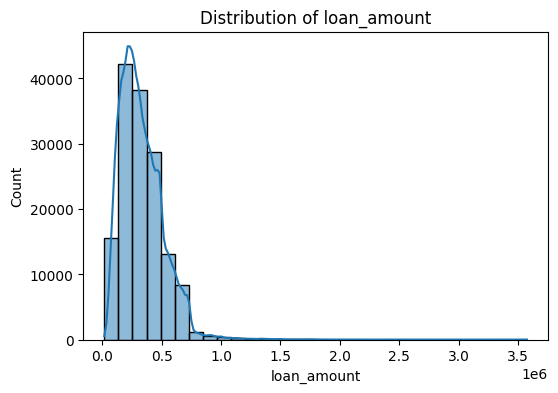

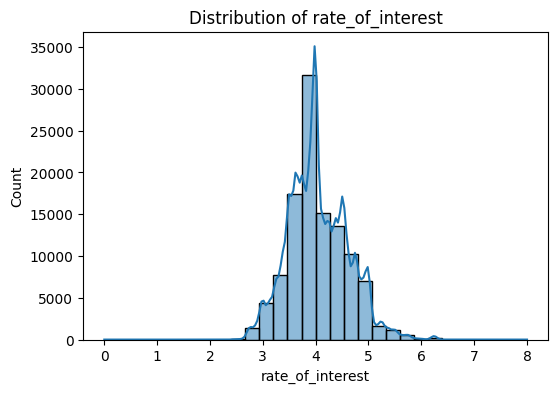

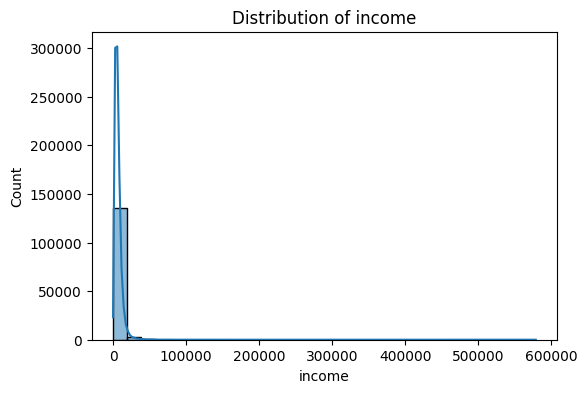

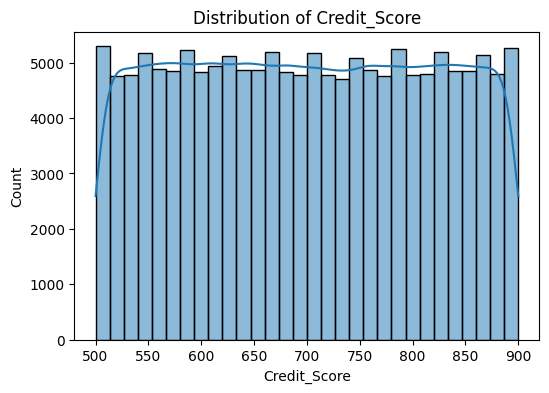

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['loan_amount', 'rate_of_interest', 'income', 'Credit_Score']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


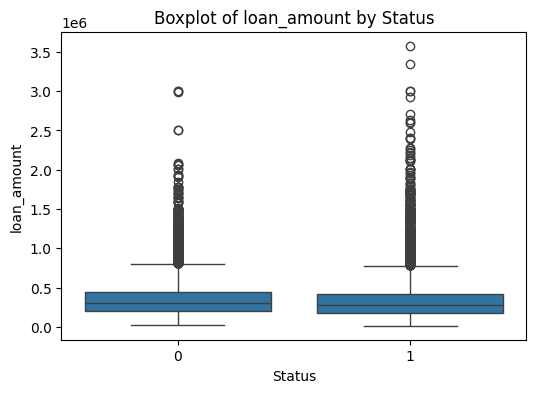

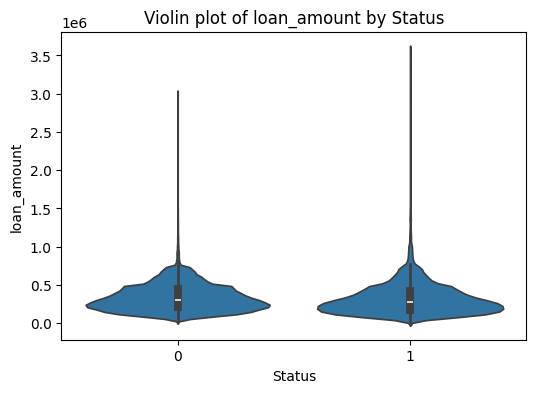

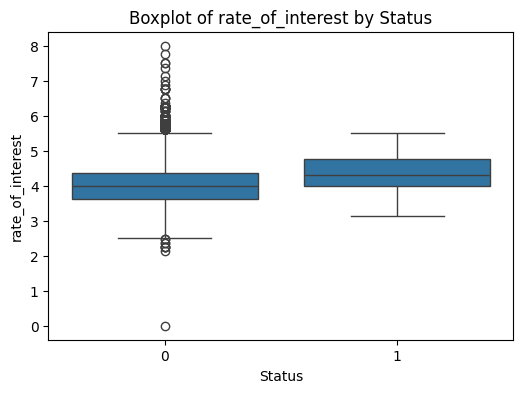

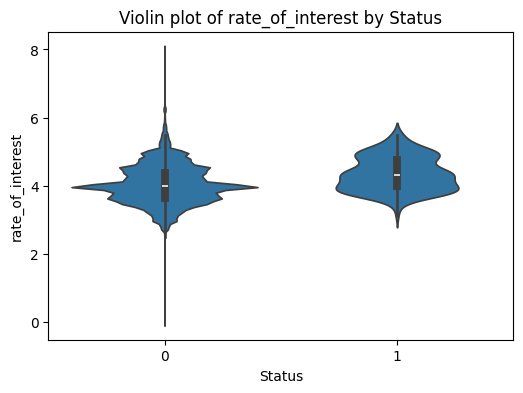

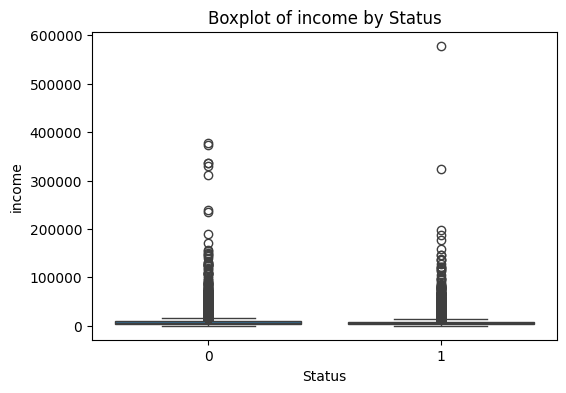

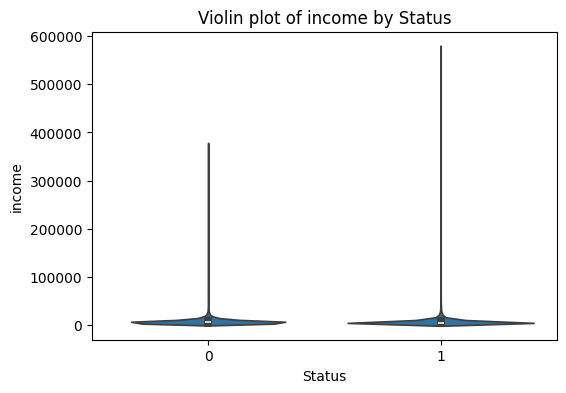

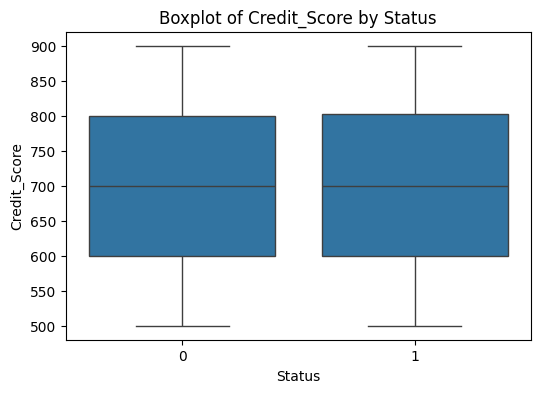

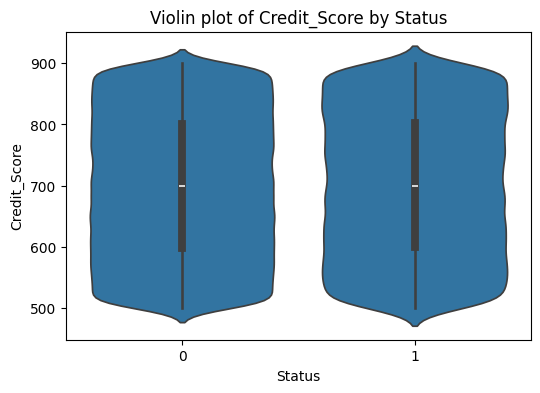

In [45]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Status', y=col, data=df)
    plt.title(f'Boxplot of {col} by Status')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.violinplot(x='Status', y=col, data=df)
    plt.title(f'Violin plot of {col} by Status')
    plt.show()


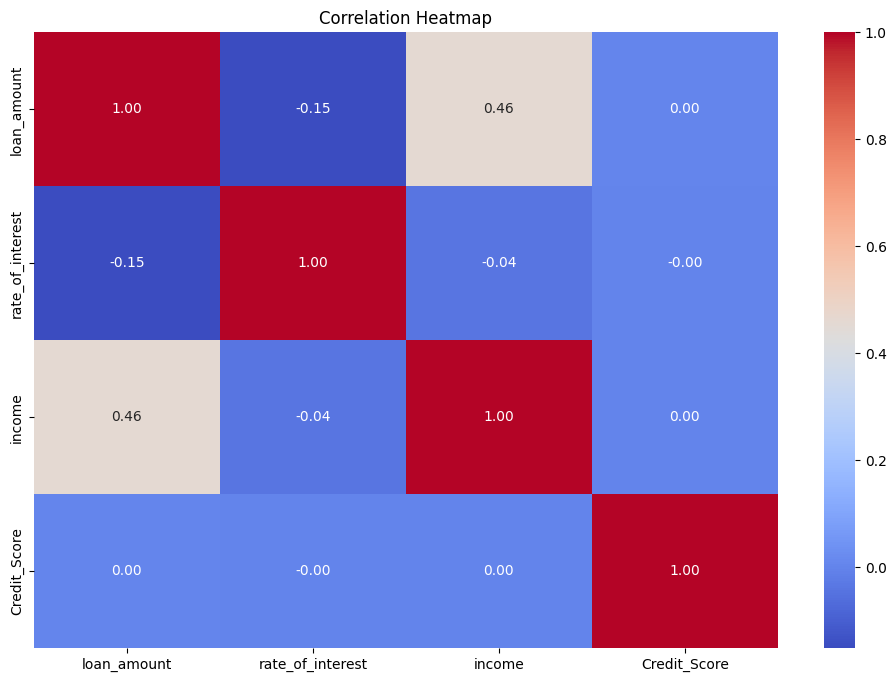

In [46]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


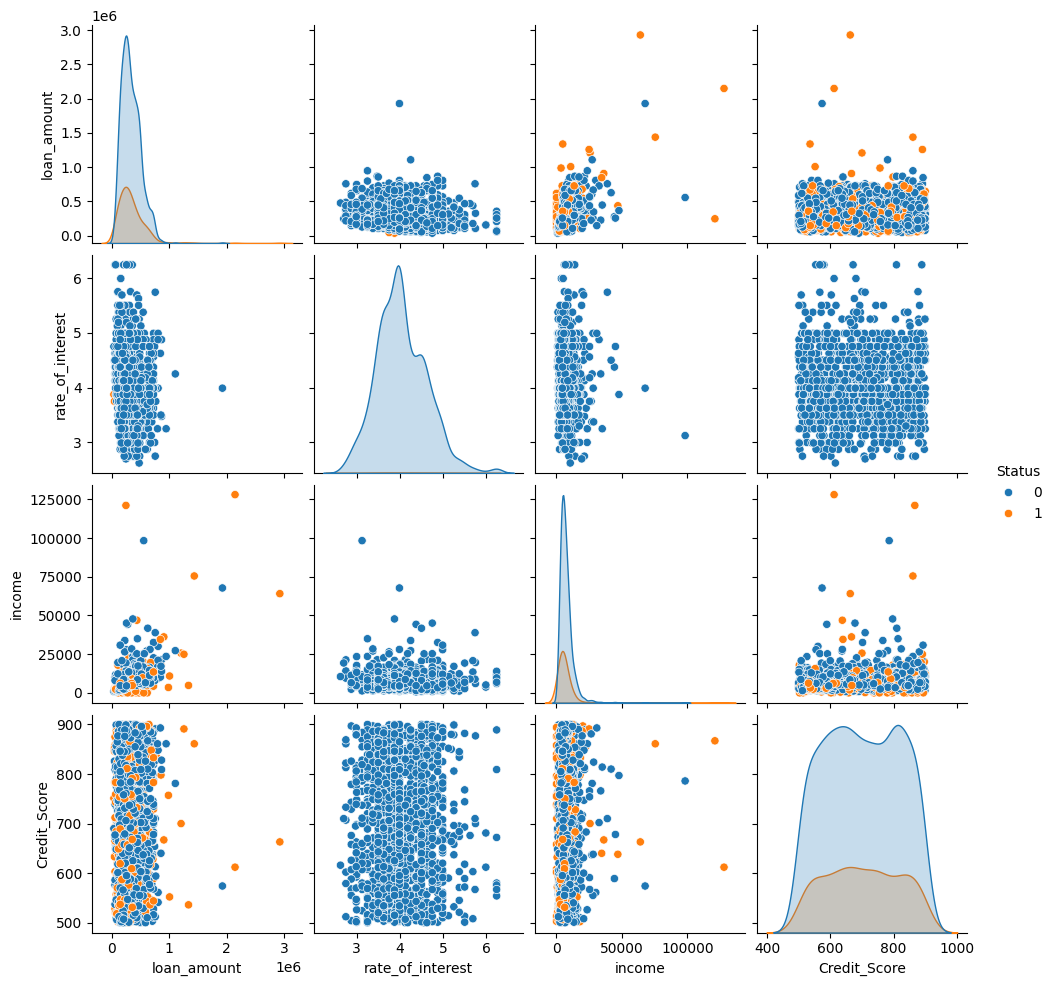

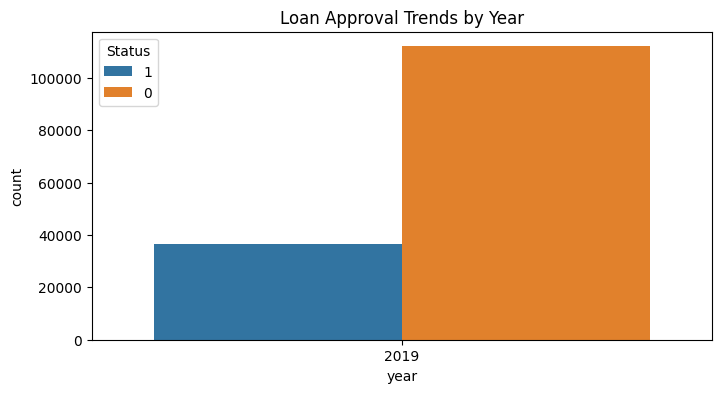

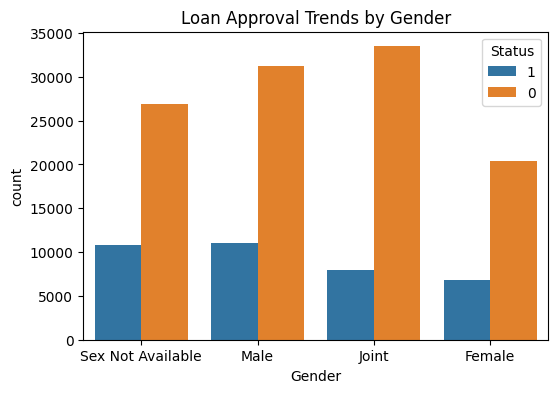

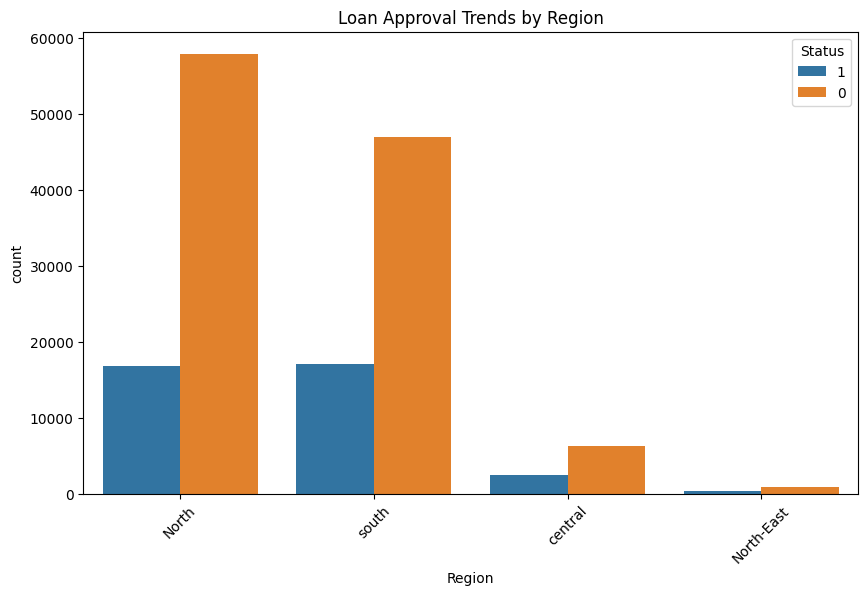

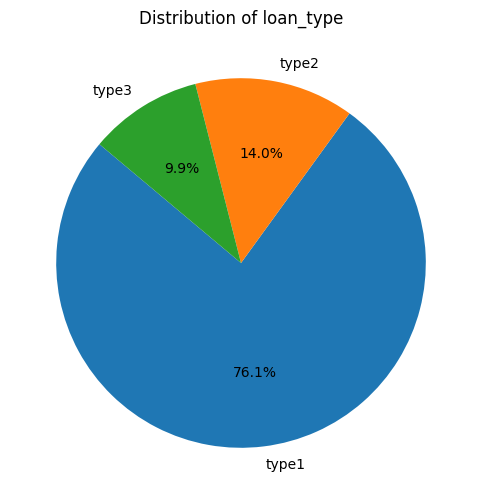

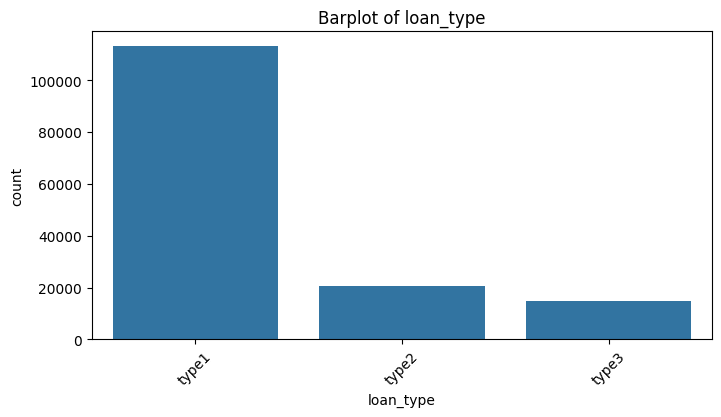

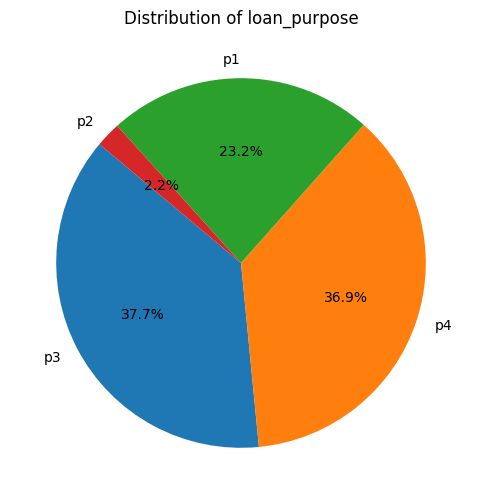

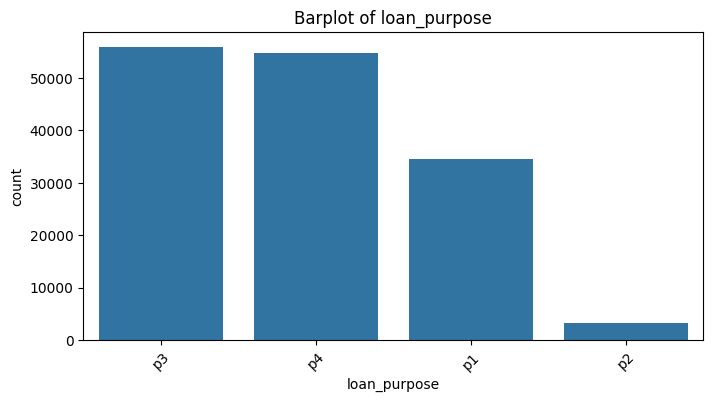

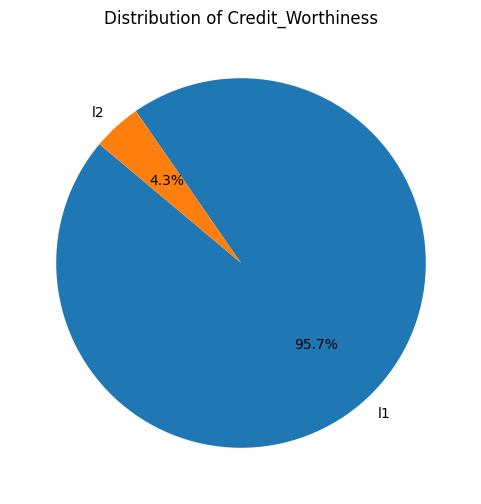

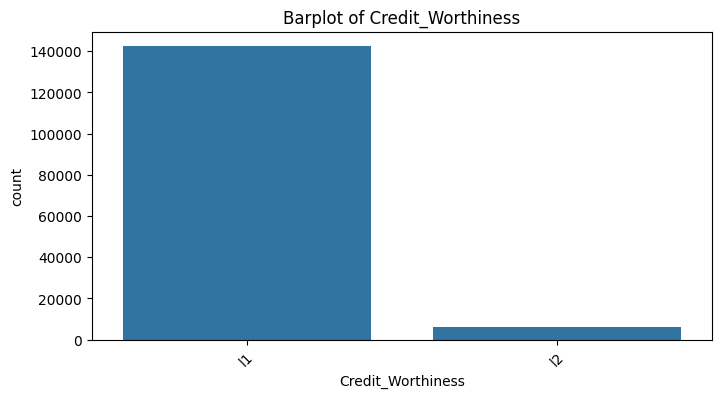

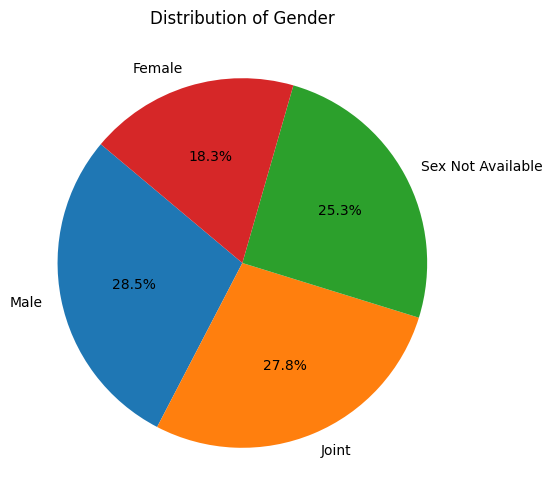

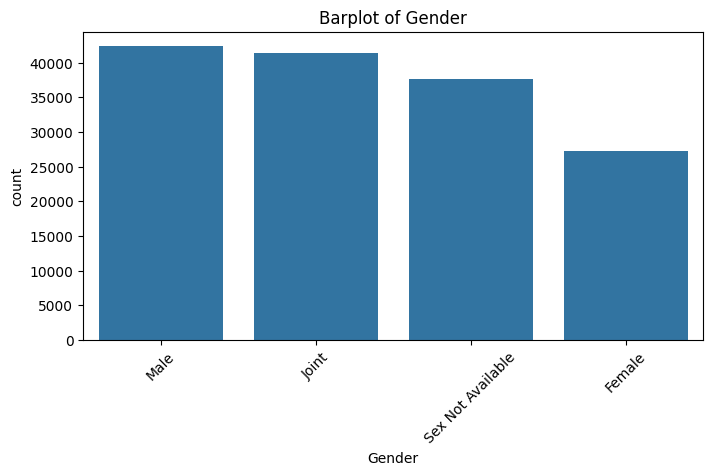

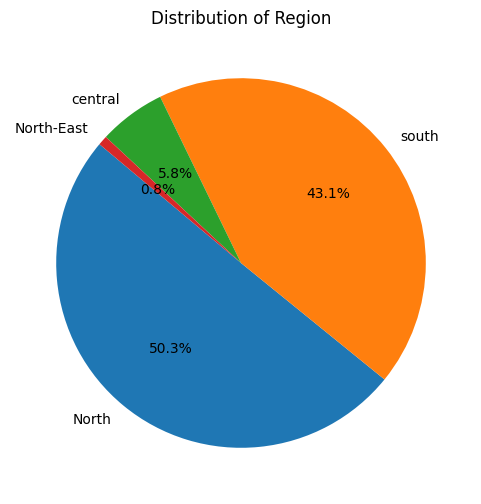

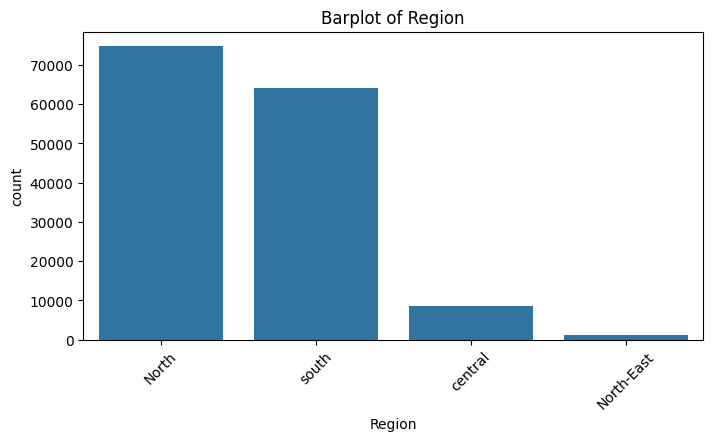

In [9]:
sample_size = 2000 if len(df) > 2000 else len(df)
sample_df = df[num_cols + [target_col]].sample(n=sample_size, random_state=42)
sns.pairplot(sample_df, hue=target_col, diag_kind='kde')
plt.show()

if 'year' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x='year', hue=target_col, data=df)
    plt.title('Loan Approval Trends by Year')
    plt.show()

if 'Gender' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='Gender', hue=target_col, data=df)
    plt.title('Loan Approval Trends by Gender')
    plt.show()

if 'Region' in df.columns:
    plt.figure(figsize=(10,6))
    sns.countplot(x='Region', hue=target_col, data=df, order=df['Region'].value_counts().index)
    plt.title('Loan Approval Trends by Region')
    plt.xticks(rotation=45)
    plt.show()
for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(6,6))
        df[col].dropna().value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
        plt.title(f'Distribution of {col}')
        plt.ylabel('')
        plt.show()

        plt.figure(figsize=(8,4))
        sns.countplot(x=col, data=df, order=df[col].value_counts().index)
        plt.title(f'Barplot of {col}')
        plt.xticks(rotation=45)
        plt.show()


/tmp/ipython-input-742865931.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percent.values, y=missing_percent.index, palette="viridis")


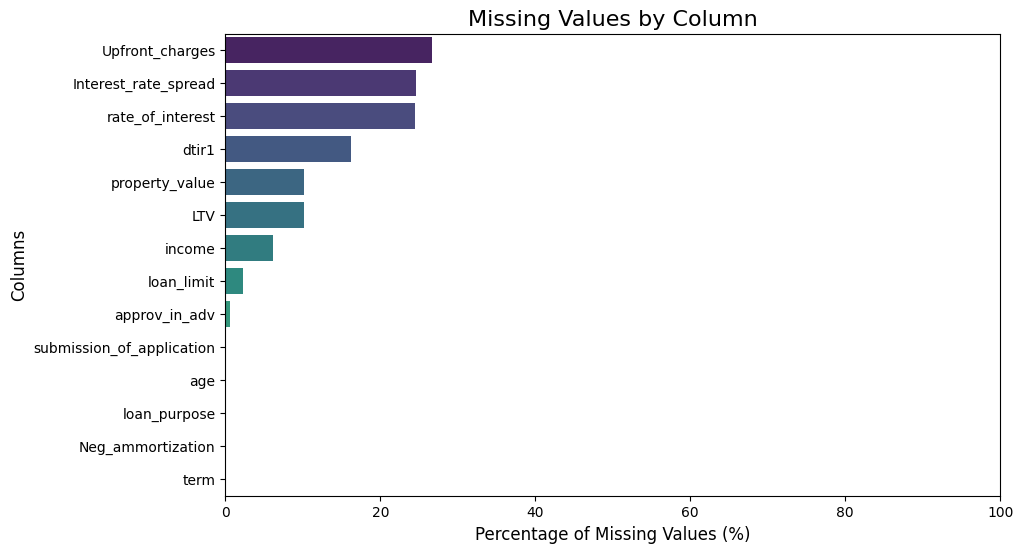

Missing Values Percentage per Column:

Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
property_value               10.155378
LTV                          10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
dtype: float64


In [11]:
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

if len(missing_percent) == 0:
    print("No missing values in the dataset!")
else:
    plt.figure(figsize=(10,6))
    sns.barplot(x=missing_percent.values, y=missing_percent.index, palette="viridis")
    plt.xlabel("Percentage of Missing Values (%)", fontsize=12)
    plt.ylabel("Columns", fontsize=12)
    plt.title("Missing Values by Column", fontsize=16)
    plt.xlim(0, 100)
    plt.show()

    print("Missing Values Percentage per Column:\n")
    print(missing_percent)